In [6]:
#某財務軟體公司在全國有許多代理商，為研究它的財務軟體產品的廣告投入與銷售額的關係，
#統計人員隨機選擇10家代理商進行觀察，搜集到年廣告投入費和月平均銷售額的數據，
#並編製成相關表
#相關係數
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

data = {'年廣告費投入':[12.5, 15.3, 23.2, 26.4, 33.5, 34.4, 39.4, 45.2, 55.4, 60.9],
        '月均銷售額':[21.2, 23.9, 32.9, 34.1, 42.5, 43.2, 49.0, 52.8, 59.4, 63.5]}

df = pd.DataFrame(data,index=range(2011,2021))
df

,年廣告費投入,月均銷售額
2011,12.5,21.2
2012,15.3,23.9
2013,23.2,32.9
2014,26.4,34.1
2015,33.5,42.5
2016,34.4,43.2
2017,39.4,49.0
2018,45.2,52.8
2019,55.4,59.4
2020,60.9,63.5


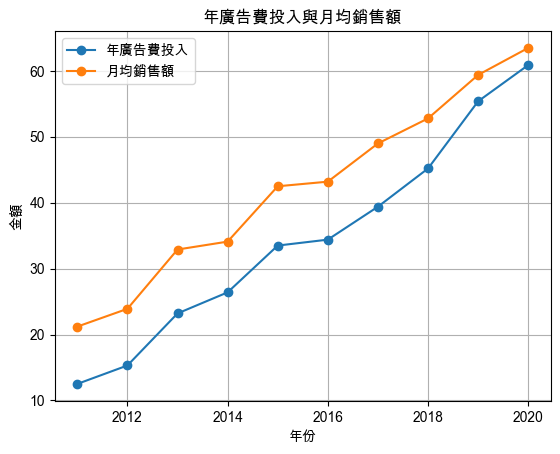

In [7]:
plt.rcParams["font.family"] = "Arial Unicode MS"
plt.rcParams["axes.unicode_minus"] = False

plt.plot(df.index, df["年廣告費投入"], marker="o", label="年廣告費投入")
plt.plot(df.index, df["月均銷售額"], marker="o", label="月均銷售額")

plt.title("年廣告費投入與月均銷售額")
plt.xlabel("年份")
plt.ylabel("金額")
plt.legend()
plt.grid(True)

plt.show()

In [8]:
df['年廣告費投入'].corr(df['月均銷售額'])

np.float64(0.9941983762371882)

In [5]:
import yfinance as yf

ticker = "2330.TW"  # 台積電

df = yf.download(
    ticker,
    start="2020-01-01",
    end="2024-12-31",
    interval="1d",
    auto_adjust=False
)

df.tail()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,2330.TW,2330.TW,2330.TW,2330.TW,2330.TW,2330.TW
Date,,,,,,
2024-12-24,1056.366699,1080.0,1095.0,1080.0,1095.0,26461906
2024-12-25,1061.257202,1085.0,1090.0,1080.0,1090.0,15481622
2024-12-26,1061.257202,1085.0,1090.0,1085.0,1085.0,14374900
2024-12-27,1066.147705,1090.0,1095.0,1080.0,1080.0,24948385
2024-12-30,1066.147705,1090.0,1095.0,1085.0,1090.0,23954634


In [3]:
import sys
sys.executable

'/Users/bonniechang/Documents/.venv/bin/python'

In [4]:
import yfinance as yf

/Users/bonniechang/Documents/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [6]:
close_df = df['Close'].reset_index()
close_df

Ticker,Date,2330.TW
0,2020-01-02,339.0
1,2020-01-03,339.5
2,2020-01-06,332.0
3,2020-01-07,329.5
4,2020-01-08,329.5
...,...,...
1209,2024-12-24,1080.0
1210,2024-12-25,1085.0
1211,2024-12-26,1085.0
1212,2024-12-27,1090.0


In [7]:
import yfinance as yf
import pandas as pd

tickers = {
    "台積電": "2330.TW",
    "聯電": "2303.TW",
    "聯發科": "2454.TW",
    "鴻海": "2317.TW",
}

# 抓 2006 年至今的歷史資料
data = yf.download(
    list(tickers.values()),
    start="2006-01-01",
    interval="1d",
    auto_adjust=True
)

# 只取收盤價
close = data["Close"]

# 把欄位名稱從股票代號改成中文公司名
code_to_name = {v: k for k, v in tickers.items()}
close = close.rename(columns=code_to_name)

print("收盤價：")
print(close.tail())

# 計算每日報酬率
returns = close.pct_change().dropna()

# 計算相關係數
corr = returns.corr()

print("\n日報酬率相關係數：")
corr

# 如果想存檔
#close.to_csv("taiwan_stocks_close_2006_to_now.csv", encoding="utf-8-sig")
#returns.to_csv("taiwan_stocks_returns_2006_to_now.csv", encoding="utf-8-sig")
#corr.to_csv("taiwan_stocks_correlation.csv", encoding="utf-8-sig")

[*********************100%***********************]  4 of 4 completed


收盤價：
Ticker         聯電          鴻海     台積電     聯發科
Date                                         
2026-06-29  164.0  239.371582  2370.0  3910.0
2026-06-30  164.5  243.741455  2410.0  4245.0
2026-07-01  169.0  240.828217  2505.0  4335.0
2026-07-02  165.5  239.000000  2465.0  4345.0
2026-07-03  170.5  240.500000  2445.0  4195.0

日報酬率相關係數：


Ticker,聯電,鴻海,台積電,聯發科
Ticker,,,,
聯電,1.000000,0.377940,0.493238,0.364842
鴻海,0.377940,1.000000,0.492494,0.377150
台積電,0.493238,0.492494,1.000000,0.449154
聯發科,0.364842,0.377150,0.449154,1.000000


In [8]:
# dictionary
tickers = {
    "台積電": "2330.TW",
    "聯電": "2303.TW",
    "聯發科": "2454.TW",
    "鴻海": "2317.TW",
}

list(tickers.values())
data = yf.download(
    list(tickers.values()),
    start="2026-01-01",
    interval="1d",
    auto_adjust=True
)

close = data['Close']

code_to_name = {v: k for k, v in tickers.items()}
close = close.rename(columns=code_to_name)
print("收盤價：")
#close.tail()
returns = close.pct_change().dropna()
corr = returns.corr()
print("\n日報酬率相關係數：")
corr

[*********************100%***********************]  4 of 4 completed

收盤價：

日報酬率相關係數：


Ticker,聯電,鴻海,台積電,聯發科
Ticker,,,,
聯電,1.000000,0.284395,0.321617,0.327949
鴻海,0.284395,1.000000,0.559397,0.505672
台積電,0.321617,0.559397,1.000000,0.411458
聯發科,0.327949,0.505672,0.411458,1.000000


In [9]:
word = 'letters'
for n in word:
    print(n)

l
e
t
t
e
r
s
